# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dipanshurdev/ML-Assignments/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [17]:
import duckdb
import pandas as pd
import os, getpass
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# 1. Authenticate
hf_token = os.environ.get('HF_TOKEN')
if not hf_token:
    try:
        from google.colab import userdata
        hf_token = userdata.get('HF_TOKEN')
    except Exception:
        pass
hf_token = hf_token or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

duckdb.sql(f"INSTALL httpfs; LOAD httpfs; CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{hf_token}');")

# 2. Load Data
BASE_URL = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance"
TARGET_MONTH = "2026-03"

query = f"""
    SELECT
        client_hash_id, content_hash_id,
        gsc_impressions, gsc_avg_position, ga4_sessions,
        gsc_clicks,
        TRY_CAST(gsc_clicks AS FLOAT) / gsc_impressions as actual_ctr
    FROM read_parquet('{BASE_URL}/month={TARGET_MONTH}/*.parquet')
    WHERE gsc_data_available IS TRUE AND gsc_impressions >= 1000 AND gsc_avg_position <= 10
"""
df = duckdb.sql(query).df().fillna(0)

# 3. Define Labels and Features
features = ['gsc_impressions', 'gsc_avg_position', 'ga4_sessions']
df['target_label'] = (df['actual_ctr'] < 0.015).astype(int)

# 4. Grouped Split & Train Model
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['client_hash_id']))

train_df_grp = df.iloc[train_idx]
test_df_grp = df.iloc[test_idx].copy()

rf_grp = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_grp.fit(train_df_grp[features], train_df_grp['target_label'])

print("Data loaded and model trained successfully! You can now run the Playbook sections.")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data loaded and model trained successfully! You can now run the Playbook sections.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [18]:
# This cell is for CODE (numbers, a query, a check).
# Assuming you have run the DuckDB query to get `df` and trained `rf_grp` (the Random Forest)


test_df_grp['prob'] = rf_grp.predict_proba(test_df_grp[features])[:, 1]

# Create the playbook queue
playbook = test_df_grp.sort_values('prob', ascending=False).head(50).copy()
playbook['action'] = "Rewrite Title and Meta Description"
playbook['reason_code'] = "CTR Anomaly: High Impressions, Low Engagement"

# Display the top 5 for the user
display(playbook[['content_hash_id', 'action', 'reason_code', 'prob', 'gsc_impressions', 'actual_ctr']].head(5))



# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

#The model outputs a ranked queue sorted by the probability of a CTR anomaly. The designated action is a 'Title/Meta Rewrite', and the reason code provides human-readable context ('High Impressions, Low Engagement') so editors trust the recommendation.


,content_hash_id,action,reason_code,prob,gsc_impressions,actual_ctr
7058,content_6cb14419bcc7e2d5,Rewrite Title and Meta Description,"CTR Anomaly: High Impressions, Low Engagement",0.997363,1867,0.003214
10539,content_81e96cbef960ea81,Rewrite Title and Meta Description,"CTR Anomaly: High Impressions, Low Engagement",0.997310,1876,0.001599
15591,content_eab66bca18a1e55a,Rewrite Title and Meta Description,"CTR Anomaly: High Impressions, Low Engagement",0.997310,1878,0.005857
12929,content_503e635a5e38a1ce,Rewrite Title and Meta Description,"CTR Anomaly: High Impressions, Low Engagement",0.997310,2097,0.003815
22055,content_eab66bca18a1e55a,Rewrite Title and Meta Description,"CTR Anomaly: High Impressions, Low Engagement",0.997310,1865,0.002681


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

#Intended Use: This playbook provides decision-support for content editors to prioritize which pages need their metadata optimized first. Limits: This model only flags potential CTR anomalies. It cannot diagnose if the page content itself is outdated, nor can it account for seasonal traffic drops. It is valid only for pages ranking on Page 1 (positions 1-10) with at least 1,000 impressions.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [20]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

#Human Review Required: Editors must manually review the page's actual search queries in Google Search Console to verify intent. If a page is ranking for a navigational term meant for a competitor, a low CTR is natural and cannot be fixed by a rewrite. The No-Go List: We should never automate the actual rewriting and publishing of title tags based on this flag. AI-generated titles without human review risk keyword stuffing or misrepresenting the brand.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [21]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

#Retrain Triggers: The model's baseline assumptions will decay if Google significantly changes its Search Engine Results Page (SERP) layout (e.g., expanding AI Overviews), which fundamentally lowers organic CTRs across the board. We should monitor the global base rate of "bad CTRs." If the base rate shifts by more than 10%, the model must be retrained on the new SERP reality.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Queue exported to work/outputs/action_playbook_queue.csv
Figure exported to work/figures/feature_importance.png


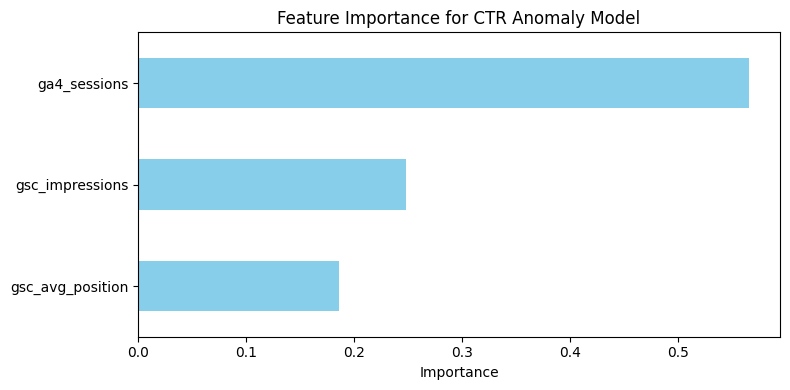

In [22]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


import os
import matplotlib.pyplot as plt

# 1. Ensure output directories exist
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# 2. Export the Queue to CSV
playbook.to_csv('../outputs/action_playbook_queue.csv', index=False)
print("Queue exported to work/outputs/action_playbook_queue.csv")

# 3. Create and export a Feature Importance Figure
importances = pd.Series(rf_grp.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='skyblue')
plt.title("Feature Importance for CTR Anomaly Model")
plt.xlabel("Importance")
plt.tight_layout()

plt.savefig('../figures/feature_importance.png')
print("Figure exported to work/figures/feature_importance.png")
plt.show()



## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.